In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import pandas as pd


In [ ]:
import os
import shutil
import pathlib

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
workspace = "/content/drive/My Drive/disfluencias/"

In [ ]:
print(os.listdir(workspace))

['creacion dataset.ipynb', 'Construction_of_Resources_for_the_Detection_and_Automatic_Classification_of_Stuttering_Induced_Disfluencies_in_Spanish (3).pdf', 'lecturas', 'RELACION DE LECTURAS.xlsx', 'disfluent_detection.ipynb', 'anotaciones.csv', 'clips', 'binary_disfluency_model.pt', 'multilabel_disfluency_model.pt', 'splits', 'sintetic_speakers', 'real_speakers', 'disfluencias_general.csv', 'pipeline_outputs_v3', 'Clasificador.ipynb']


In [ ]:
anotaciones = pd.read_csv(workspace + "anotaciones.csv")

In [ ]:
anotaciones.head()

,Show,EpId,ClipId,Resources,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech
0,ATMA,2020-05-27_03_54_34,14,https://drive.google.com/file/d/1EsFDqdj7lkdMk...,711326,759326,0,0,0,0,0,0,0,0,1,0,0,0
1,ATMA,2020-05-27_03_54_34,19,https://drive.google.com/file/d/1Ev0o32TbZS4DB...,909896,957896,0,0,0,0,0,0,0,0,1,0,0,0
2,ATMA,2020-05-27_03_54_34,20,https://drive.google.com/file/d/1EhKi6PM2WTVDt...,947555,995555,0,0,0,0,0,0,0,0,1,0,0,0
3,ATMA,2020-05-27_03_54_34,22,https://drive.google.com/file/d/1ERoJJy0_07AFd...,1035183,1083183,1,0,0,0,0,0,0,0,0,0,0,0
4,ATMA,2020-05-27_03_55_03,1,https://drive.google.com/file/d/17yv3oBzS9HNPF...,124688,172688,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:

anotaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4705 entries, 0 to 4704
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Show                   4705 non-null   object
 1   EpId                   4705 non-null   object
 2   ClipId                 4705 non-null   int64 
 3   Resources              4705 non-null   object
 4   Start                  4705 non-null   int64 
 5   Stop                   4705 non-null   int64 
 6   Unsure                 4705 non-null   int64 
 7   PoorAudioQuality       4705 non-null   int64 
 8   Prolongation           4705 non-null   int64 
 9   Block                  4705 non-null   int64 
 10  SoundRep               4705 non-null   int64 
 11  WordRep                4705 non-null   int64 
 12  DifficultToUnderstand  4705 non-null   int64 
 13  Interjection           4705 non-null   int64 
 14  NoStutteredWords       4705 non-null   int64 
 15  NaturalPause         

In [ ]:

anotaciones.describe()

,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech
count,4705.000000,4.705000e+03,4.705000e+03,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000
mean,28.457598,1.324248e+06,1.372248e+06,0.014240,0.000638,0.116897,0.090329,0.103507,0.022104,0.005526,0.003613,0.579596,0.067375,0.033156,0.011052
std,18.814819,8.031604e+05,8.031604e+05,0.118492,0.025246,0.321332,0.286684,0.304652,0.147038,0.074140,0.060007,0.493676,0.250697,0.179063,0.104557
min,0.000000,5.639000e+03,5.363900e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,6.615220e+05,7.095220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,1.286234e+06,1.334234e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,42.000000,1.933986e+06,1.981986e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,92.000000,4.076723e+06,4.124723e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
anotaciones.columns

Index(['Show', 'EpId', 'ClipId', 'Resources', 'Start', 'Stop', 'Unsure',
       'PoorAudioQuality', 'Prolongation', 'Block', 'SoundRep', 'WordRep',
       'DifficultToUnderstand', 'Interjection', 'NoStutteredWords',
       'NaturalPause', 'Music', 'NoSpeech'],
      dtype='object')

In [ ]:
#eliminar filas donde show == HELR,
anotaciones = anotaciones[anotaciones['Show'] != 'HELR']

In [ ]:
#mostrar valores unicos de la columna EpID
print(anotaciones['Show'].unique())

['ATMA' 'LPJM' 'PVM' 'RRYR' 'SSF']


In [ ]:
print(anotaciones['Unsure'].value_counts())
print(anotaciones['PoorAudioQuality'].value_counts())
print(anotaciones['Prolongation'].value_counts())
print(anotaciones['Block'].value_counts())
print(anotaciones['SoundRep'].value_counts())
print(anotaciones['WordRep'].value_counts())
print(anotaciones['DifficultToUnderstand'].value_counts())
print(anotaciones['Interjection'].value_counts())
print(anotaciones['NoStutteredWords'].value_counts())
print(anotaciones['NaturalPause'].value_counts())
print(anotaciones['Music'].value_counts())
print(anotaciones['NoSpeech'].value_counts())

Unsure
0    4638
1      67
Name: count, dtype: int64
PoorAudioQuality
0    4702
1       3
Name: count, dtype: int64
Prolongation
0    4155
1     550
Name: count, dtype: int64
Block
0    4280
1     425
Name: count, dtype: int64
SoundRep
0    4218
1     487
Name: count, dtype: int64
WordRep
0    4601
1     104
Name: count, dtype: int64
DifficultToUnderstand
0    4679
1      26
Name: count, dtype: int64
Interjection
0    4688
1      17
Name: count, dtype: int64
NoStutteredWords
1    2727
0    1978
Name: count, dtype: int64
NaturalPause
0    4388
1     317
Name: count, dtype: int64
Music
0    4549
1     156
Name: count, dtype: int64
NoSpeech
0    4653
1      52
Name: count, dtype: int64


### Data Preparation

In [ ]:
import librosa
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
filtered_anotaciones = anotaciones[
    (anotaciones['PoorAudioQuality'] == 0) &
    (anotaciones['DifficultToUnderstand'] == 0)
].copy()

In [ ]:
print(f"Original annotations: {len(anotaciones)} rows")
print(f"Filtered annotations (PoorAudioQuality=0, DifficultToUnderstand=0): {len(filtered_anotaciones)} rows")

Original annotations: 4705 rows
Filtered annotations (PoorAudioQuality=0, DifficultToUnderstand=0): 4676 rows


In [ ]:
disfluency_labels = ['Prolongation', 'Block', 'SoundRep', 'WordRep', 'Interjection']

In [ ]:
filtered_anotaciones['is_disfluent'] = filtered_anotaciones[disfluency_labels].any(axis=1).astype(int)


In [ ]:
filtered_anotaciones.columns

Index(['Show', 'EpId', 'ClipId', 'Resources', 'Start', 'Stop', 'Unsure',
       'PoorAudioQuality', 'Prolongation', 'Block', 'SoundRep', 'WordRep',
       'DifficultToUnderstand', 'Interjection', 'NoStutteredWords',
       'NaturalPause', 'Music', 'NoSpeech', 'is_disfluent'],
      dtype='object')

In [ ]:
filtered_anotaciones.head()

,Show,EpId,ClipId,Resources,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech,is_disfluent
0,ATMA,2020-05-27_03_54_34,14,https://drive.google.com/file/d/1EsFDqdj7lkdMk...,711326,759326,0,0,0,0,0,0,0,0,1,0,0,0,0
1,ATMA,2020-05-27_03_54_34,19,https://drive.google.com/file/d/1Ev0o32TbZS4DB...,909896,957896,0,0,0,0,0,0,0,0,1,0,0,0,0
2,ATMA,2020-05-27_03_54_34,20,https://drive.google.com/file/d/1EhKi6PM2WTVDt...,947555,995555,0,0,0,0,0,0,0,0,1,0,0,0,0
3,ATMA,2020-05-27_03_54_34,22,https://drive.google.com/file/d/1ERoJJy0_07AFd...,1035183,1083183,1,0,0,0,0,0,0,0,0,0,0,0,0
4,ATMA,2020-05-27_03_55_03,1,https://drive.google.com/file/d/17yv3oBzS9HNPF...,124688,172688,0,0,0,0,0,0,0,0,1,0,0,0,0


#### Descargar clips de audios del dataframe

In [ ]:
import gdown
import re

In [ ]:
clips_dir = os.path.join(workspace, "clips")

In [ ]:
# Create the clips directory if it doesn't exist
os.makedirs(clips_dir, exist_ok=True)
print(f"Created directory: {clips_dir}")

Created directory: /content/drive/My Drive/disfluencias/clips


In [ ]:
def get_drive_file_id(url):
    match = re.search(r'/file/d/([a-zA-Z0-9_-]+)', url)
    if match:
        return match.group(1)
    return None

In [ ]:
downloaded_clips_data = []

Esto es para descargar los audios si ya esta creado no ejecutar esta celda

In [ ]:
print("Starting download of audio clips...")
for index, row in anotaciones.iterrows():
    clip_id = row['ClipId']
    resources_url = row['Resources']
    speaker = row['Show'] # Get the speaker's name
    ep_id = row['EpId'] # Get the EpId for the current row

    # Get Google Drive file ID
    file_id = get_drive_file_id(resources_url)

    if file_id:
        # Define the speaker-specific subdirectory
        speaker_clips_dir = os.path.join(clips_dir, speaker)
        os.makedirs(speaker_clips_dir, exist_ok=True) # Create speaker's directory if it doesn't exist

        # Define the EpId-specific subdirectory within the speaker's directory
        epid_clips_dir = os.path.join(speaker_clips_dir, str(ep_id))
        os.makedirs(epid_clips_dir, exist_ok=True) # Create EpId's directory if it doesn't exist

        # Define the target filename and path within the EpId's directory
        output_filename = f"{clip_id}.wav"
        output_path = os.path.join(epid_clips_dir, output_filename)

        # Check if the file already exists to avoid re-downloading
        if os.path.exists(output_path):
            print(f"Skipping {output_filename} for speaker {speaker}, EpId {ep_id}: Already exists.")
        else:
            try:
                # Download the file using gdown
                gdown.download(id=file_id, output=output_path, quiet=True)
                print(f"Downloaded {output_filename} to {output_path}")
            except Exception as e:
                print(f"Error downloading {output_filename} (ID: {file_id}) for speaker {speaker}, EpId {ep_id}: {e}")
                output_path = None # Mark as failed download

        if output_path:
            # Add to the list for the new DataFrame, including 'Show' and 'EpId'
            downloaded_clips_data.append({"Show": speaker, "EpId": ep_id, "ClipId": clip_id, "wav_audio_path": output_path})
    else:
        print(f"Could not extract Google Drive file ID from URL: {resources_url} for ClipId: {clip_id}")

# Create the new DataFrame
clips_info_df = pd.DataFrame(downloaded_clips_data)

Starting download of audio clips...
Skipping 14.wav for speaker ATMA, EpId 2020-05-27_03_54_34: Already exists.
Skipping 19.wav for speaker ATMA, EpId 2020-05-27_03_54_34: Already exists.
Skipping 20.wav for speaker ATMA, EpId 2020-05-27_03_54_34: Already exists.
Skipping 22.wav for speaker ATMA, EpId 2020-05-27_03_54_34: Already exists.
Skipping 1.wav for speaker ATMA, EpId 2020-05-27_03_55_03: Already exists.
Skipping 9.wav for speaker ATMA, EpId 2020-05-27_03_55_03: Already exists.
Skipping 14.wav for speaker ATMA, EpId 2020-05-27_03_55_03: Already exists.
Skipping 24.wav for speaker ATMA, EpId 2020-05-27_03_55_03: Already exists.
Skipping 31.wav for speaker ATMA, EpId 2020-05-27_03_55_03: Already exists.
Skipping 1.wav for speaker ATMA, EpId 2020-05-27_03_55_25: Already exists.
Skipping 8.wav for speaker ATMA, EpId 2020-05-27_03_55_25: Already exists.
Skipping 15.wav for speaker ATMA, EpId 2020-05-27_03_55_25: Already exists.
Skipping 31.wav for speaker ATMA, EpId 2020-05-27_03_55_

In [ ]:
clips_info_df.head()

,Show,EpId,ClipId,wav_audio_path
0,ATMA,2020-05-27_03_54_34,14,/content/drive/My Drive/disfluencias/clips/ATM...
1,ATMA,2020-05-27_03_54_34,19,/content/drive/My Drive/disfluencias/clips/ATM...
2,ATMA,2020-05-27_03_54_34,20,/content/drive/My Drive/disfluencias/clips/ATM...
3,ATMA,2020-05-27_03_54_34,22,/content/drive/My Drive/disfluencias/clips/ATM...
4,ATMA,2020-05-27_03_55_03,1,/content/drive/My Drive/disfluencias/clips/ATM...


In [ ]:
# Merge filtered_anotaciones with clips_info_df to add the audio file paths
# The merge keys are 'Show', 'EpId', and 'ClipId' to ensure correct linking.
anotaciones_with_audio_paths = pd.merge(
    filtered_anotaciones,
    clips_info_df,
    on=['Show', 'EpId', 'ClipId'],
    how='left'  # Use left merge to keep all rows from filtered_anotaciones
)

# Display the first few rows of the merged DataFrame to verify
print("First 5 rows of annotations with audio paths:")
display(anotaciones_with_audio_paths.head())

# Check for any missing audio paths (should ideally be none if all downloaded successfully)
missing_audio_paths = anotaciones_with_audio_paths['wav_audio_path'].isnull().sum()
if missing_audio_paths > 0:
    print(f"\nWarning: {missing_audio_paths} rows have missing audio paths after merge. This might indicate issues during download or with merge keys.")


First 5 rows of annotations with audio paths:


,Show,EpId,ClipId,Resources,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,WordRep,DifficultToUnderstand,Interjection,NoStutteredWords,NaturalPause,Music,NoSpeech,is_disfluent,wav_audio_path
0,ATMA,2020-05-27_03_54_34,14,https://drive.google.com/file/d/1EsFDqdj7lkdMk...,711326,759326,0,0,0,0,0,0,0,0,1,0,0,0,0,/content/drive/My Drive/disfluencias/clips/ATM...
1,ATMA,2020-05-27_03_54_34,19,https://drive.google.com/file/d/1Ev0o32TbZS4DB...,909896,957896,0,0,0,0,0,0,0,0,1,0,0,0,0,/content/drive/My Drive/disfluencias/clips/ATM...
2,ATMA,2020-05-27_03_54_34,20,https://drive.google.com/file/d/1EhKi6PM2WTVDt...,947555,995555,0,0,0,0,0,0,0,0,1,0,0,0,0,/content/drive/My Drive/disfluencias/clips/ATM...
3,ATMA,2020-05-27_03_54_34,22,https://drive.google.com/file/d/1ERoJJy0_07AFd...,1035183,1083183,1,0,0,0,0,0,0,0,0,0,0,0,0,/content/drive/My Drive/disfluencias/clips/ATM...
4,ATMA,2020-05-27_03_55_03,1,https://drive.google.com/file/d/17yv3oBzS9HNPF...,124688,172688,0,0,0,0,0,0,0,0,1,0,0,0,0,/content/drive/My Drive/disfluencias/clips/ATM...


### Feature Extraction: MFCCs

Now we will extract MFCC (Mel-Frequency Cepstral Coefficients) features from each audio clip. MFCCs are a common choice for audio processing tasks, representing the short-term power spectrum of a sound.

For each audio clip, we will extract a set of MFCCs and then compute their mean and standard deviation across time. This will give us a fixed-size feature vector for each clip, which is suitable for traditional machine learning models like Logistic Regression and Random Forest.

In [ ]:
import librosa
import numpy as np
import warnings

In [ ]:
# Suppress librosa warnings (e.g., about audio loading conversions)
warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
def extract_mfcc_features(audio_path, sr=16000, n_mfcc=40):
    """
    Extracts MFCC features (mean and standard deviation) from an audio file.

    Args:
        audio_path (str): Path to the audio file.
        sr (int): Target sampling rate. Defaults to 16000.
        n_mfcc (int): Number of MFCCs to extract. Defaults to 40.

    Returns:
        np.ndarray: Concatenated mean and std of MFCCs, or None if an error occurs.
    """
    if not os.path.exists(audio_path):
        # print(f"Warning: Audio file not found: {audio_path}. Skipping feature extraction.")
        return None
    try:
        audio, _ = librosa.load(audio_path, sr=sr, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

        # Compute mean and standard deviation across time for each MFCC coefficient
        mfccs_mean = np.mean(mfccs, axis=1)
        mfccs_std = np.std(mfccs, axis=1)

        # Concatenate mean and std to form a single feature vector
        return np.hstack((mfccs_mean, mfccs_std))
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [ ]:
print("Extracting MFCC features from audio clips. This may take a while...")
# Apply the feature extraction function to the DataFrame
# We'll create a new DataFrame for features and labels for clarity
mfcc_data = []

Extracting MFCC features from audio clips. This may take a while...


In [ ]:
# Assuming anotaciones_with_audio_paths is the DataFrame with 'wav_audio_path' and individual disfluency type columns
for index, row in anotaciones_with_audio_paths.iterrows():
    features = extract_mfcc_features(row['wav_audio_path'])
    if features is not None:
        entry = {
            'mfcc_features': features,
            'is_disfluent': row['is_disfluent'] # Keep binary disfluency status
        }
        # Add individual disfluency types to the entry
        for label in disfluency_labels:
            entry[label] = row[label]
        mfcc_data.append(entry)


In [ ]:
mfcc_df = pd.DataFrame(mfcc_data)

In [ ]:
mfcc_df.head()

,mfcc_features,is_disfluent,Prolongation,Block,SoundRep,WordRep,Interjection
0,"[-242.62027, 144.81525, -32.077698, 26.666449,...",0,0,0,0,0,0
1,"[-266.70572, 147.1005, -19.300808, 16.636168, ...",0,0,0,0,0,0
2,"[-240.28458, 146.40851, -20.96904, 14.8378105,...",0,0,0,0,0,0
3,"[-291.84048, 148.52306, -20.290731, 16.679974,...",0,0,0,0,0,0
4,"[-274.2853, 133.41849, -2.2127957, 7.824939, 7...",0,0,0,0,0,0


In [ ]:
mfcc_df = pd.DataFrame(mfcc_data)

In [ ]:
# Separate features (X) and target (y)
X_mfcc = np.array(mfcc_df['mfcc_features'].tolist())
y_mfcc = mfcc_df['is_disfluent']


In [ ]:
print(f"Finished MFCC feature extraction. Shape of features: {X_mfcc.shape}")
print(f"Number of samples with extracted MFCCs: {len(mfcc_df)}")

Finished MFCC feature extraction. Shape of features: (4676, 80)
Number of samples with extracted MFCCs: 4676


In [ ]:
X_train_mfcc, X_temp_mfcc, y_train_mfcc, y_temp_mfcc = train_test_split(
    X_mfcc, y_mfcc, test_size=0.66, random_state=42, stratify=y_mfcc
)

In [ ]:
# Then split temp (66%) into validation (33%) and test (33%)
X_val_mfcc, X_test_mfcc, y_val_mfcc, y_test_mfcc = train_test_split(
    X_temp_mfcc, y_temp_mfcc, test_size=0.5, random_state=42, stratify=y_temp_mfcc
)

In [ ]:
print(f"\nMFCC Dataset Splits:")
print(f"Train set: {len(X_train_mfcc)} samples - Disfluent: {y_train_mfcc.sum()} ({y_train_mfcc.mean():.2%})")
print(f"Validation set: {len(X_val_mfcc)} samples - Disfluent: {y_val_mfcc.sum()} ({y_val_mfcc.mean():.2%})")
print(f"Test set: {len(X_test_mfcc)} samples - Disfluent: {y_test_mfcc.sum()} ({y_test_mfcc.mean():.2%})")


MFCC Dataset Splits:
Train set: 1589 samples - Disfluent: 470 (29.58%)
Validation set: 1543 samples - Disfluent: 456 (29.55%)
Test set: 1544 samples - Disfluent: 456 (29.53%)


### Baseline Models: Logistic Regression and Random Forest (with MFCCs)

Now that we have extracted MFCC features, we can train our baseline machine learning models: Logistic Regression and Random Forest. We will evaluate their performance using accuracy and a classification report.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
log_reg_model.fit(X_train_mfcc, y_train_mfcc)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [ ]:
y_pred_val_log_reg = log_reg_model.predict(X_val_mfcc)

In [ ]:
print(f"Logistic Regression Validation Accuracy: {accuracy_score(y_val_mfcc, y_pred_val_log_reg):.4f}")
print("Logistic Regression Validation Report:\n", classification_report(y_val_mfcc, y_pred_val_log_reg))


Logistic Regression Validation Accuracy: 0.7058
Logistic Regression Validation Report:
               precision    recall  f1-score   support

           0       0.74      0.91      0.81      1087
           1       0.50      0.23      0.31       456

    accuracy                           0.71      1543
   macro avg       0.62      0.57      0.56      1543
weighted avg       0.67      0.71      0.67      1543



In [ ]:
# Evaluate on Test set
y_pred_test_log_reg = log_reg_model.predict(X_test_mfcc)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test_mfcc, y_pred_test_log_reg):.4f}")
print("Logistic Regression Test Report:\n", classification_report(y_test_mfcc, y_pred_test_log_reg))

Logistic Regression Test Accuracy: 0.6975
Logistic Regression Test Report:
               precision    recall  f1-score   support

           0       0.74      0.89      0.81      1088
           1       0.48      0.23      0.31       456

    accuracy                           0.70      1544
   macro avg       0.61      0.56      0.56      1544
weighted avg       0.66      0.70      0.66      1544



### Visualización de la Regresión Logística: Matriz de Confusión

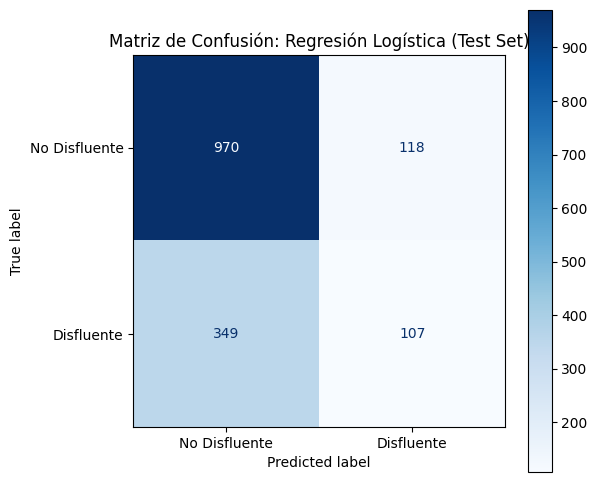

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test_mfcc, y_pred_test_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['No Disfluente', 'Disfluente'])

fig_log_reg, ax_log_reg = plt.subplots(figsize=(6, 6))
disp_log_reg.plot(cmap='Blues', ax=ax_log_reg)
ax_log_reg.set_title('Matriz de Confusión: Regresión Logística (Test Set)')
plt.show()

In [ ]:
# --- Random Forest Model ---
print("\n--- Training Random Forest Model ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train_mfcc, y_train_mfcc)



--- Training Random Forest Model ---


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
# Evaluate on Validation set
y_pred_val_rf = rf_model.predict(X_val_mfcc)
print(f"Random Forest Validation Accuracy: {accuracy_score(y_val_mfcc, y_pred_val_rf):.4f}")
print("Random Forest Validation Report:\n", classification_report(y_val_mfcc, y_pred_val_rf))

Random Forest Validation Accuracy: 0.7155
Random Forest Validation Report:
               precision    recall  f1-score   support

           0       0.72      0.97      0.83      1087
           1       0.60      0.12      0.19       456

    accuracy                           0.72      1543
   macro avg       0.66      0.54      0.51      1543
weighted avg       0.69      0.72      0.64      1543



In [ ]:
# Evaluate on Test set
y_pred_test_rf = rf_model.predict(X_test_mfcc)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test_mfcc, y_pred_test_rf):.4f}")
print("Random Forest Test Report:\n", classification_report(y_test_mfcc, y_pred_test_rf))

Random Forest Test Accuracy: 0.7092
Random Forest Test Report:
               precision    recall  f1-score   support

           0       0.72      0.95      0.82      1088
           1       0.53      0.14      0.22       456

    accuracy                           0.71      1544
   macro avg       0.63      0.54      0.52      1544
weighted avg       0.67      0.71      0.64      1544



### Visualización del Bosque Aleatorio: Matriz de Confusión e Importancia de Características

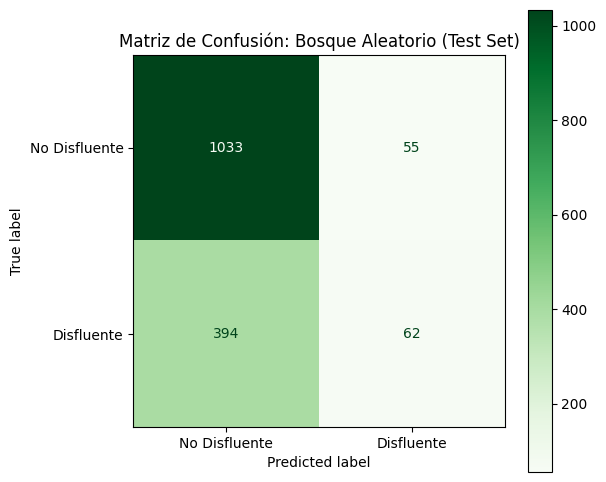

In [ ]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test_mfcc, y_pred_test_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Disfluente', 'Disfluente'])

fig_rf, ax_rf = plt.subplots(figsize=(6, 6))
disp_rf.plot(cmap='Greens', ax=ax_rf)
ax_rf.set_title('Matriz de Confusión: Bosque Aleatorio (Test Set)')
plt.show()

In [ ]:
import seaborn as sns

/tmp/ipykernel_538/1304509586.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.head(20).values, y=sorted_importances.head(20).index, palette='viridis')


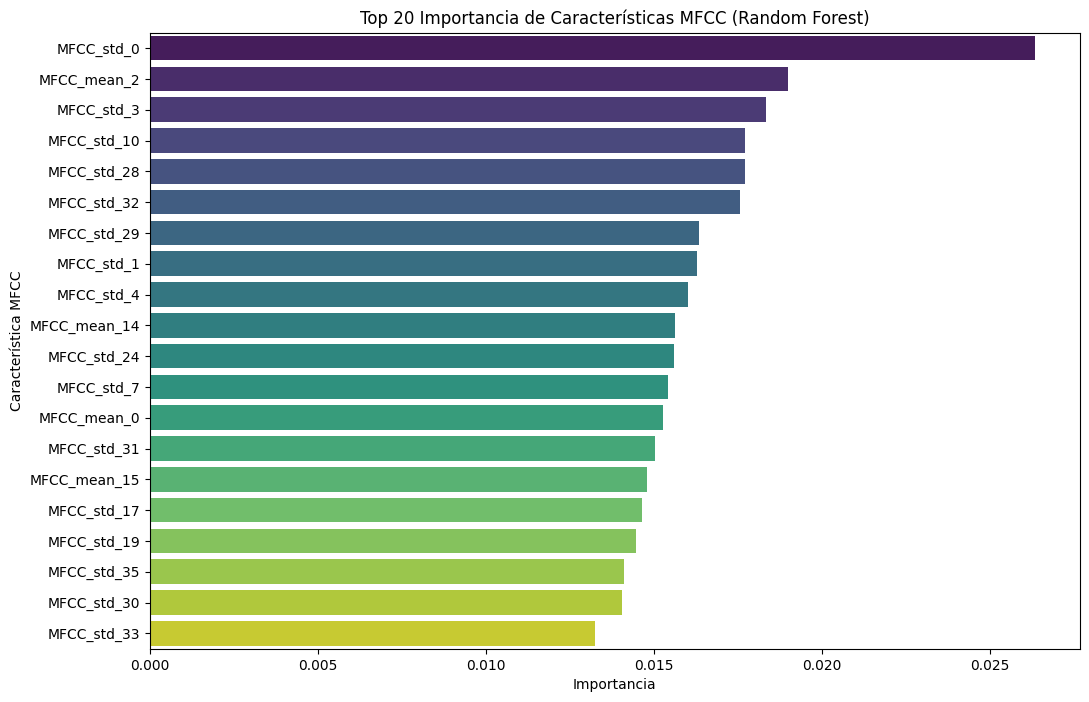

In [ ]:
# Feature Importance for Random Forest

import seaborn as sns

# Create names for MFCC features (e.g., MFCC_mean_0, MFCC_std_0, etc.)
num_mfccs = X_mfcc.shape[1] // 2
mfcc_feature_names = [f'MFCC_mean_{i}' for i in range(num_mfccs)] + \
                     [f'MFCC_std_{i}' for i in range(num_mfccs)]

# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# Create a Series for easy sorting and plotting
feature_importances_series = pd.Series(importances, index=mfcc_feature_names)

# Sort the features by importance
sorted_importances = feature_importances_series.sort_values(ascending=False)

# Plot the top N features (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.head(20).values, y=sorted_importances.head(20).index, palette='viridis')
plt.title('Top 20 Importancia de Características MFCC (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica MFCC')
plt.show()

### Visualización de un Árbol Individual del Bosque Aleatorio

El `RandomForestClassifier` se construye a partir de múltiples árboles de decisión. A continuación, se muestra cómo visualizar uno de estos árboles para entender su estructura de toma de decisiones.

*(Nota: Visualizar todos los árboles puede ser computacionalmente intensivo y generar gráficos muy grandes, por lo que se muestra solo el primer árbol como ejemplo.)*

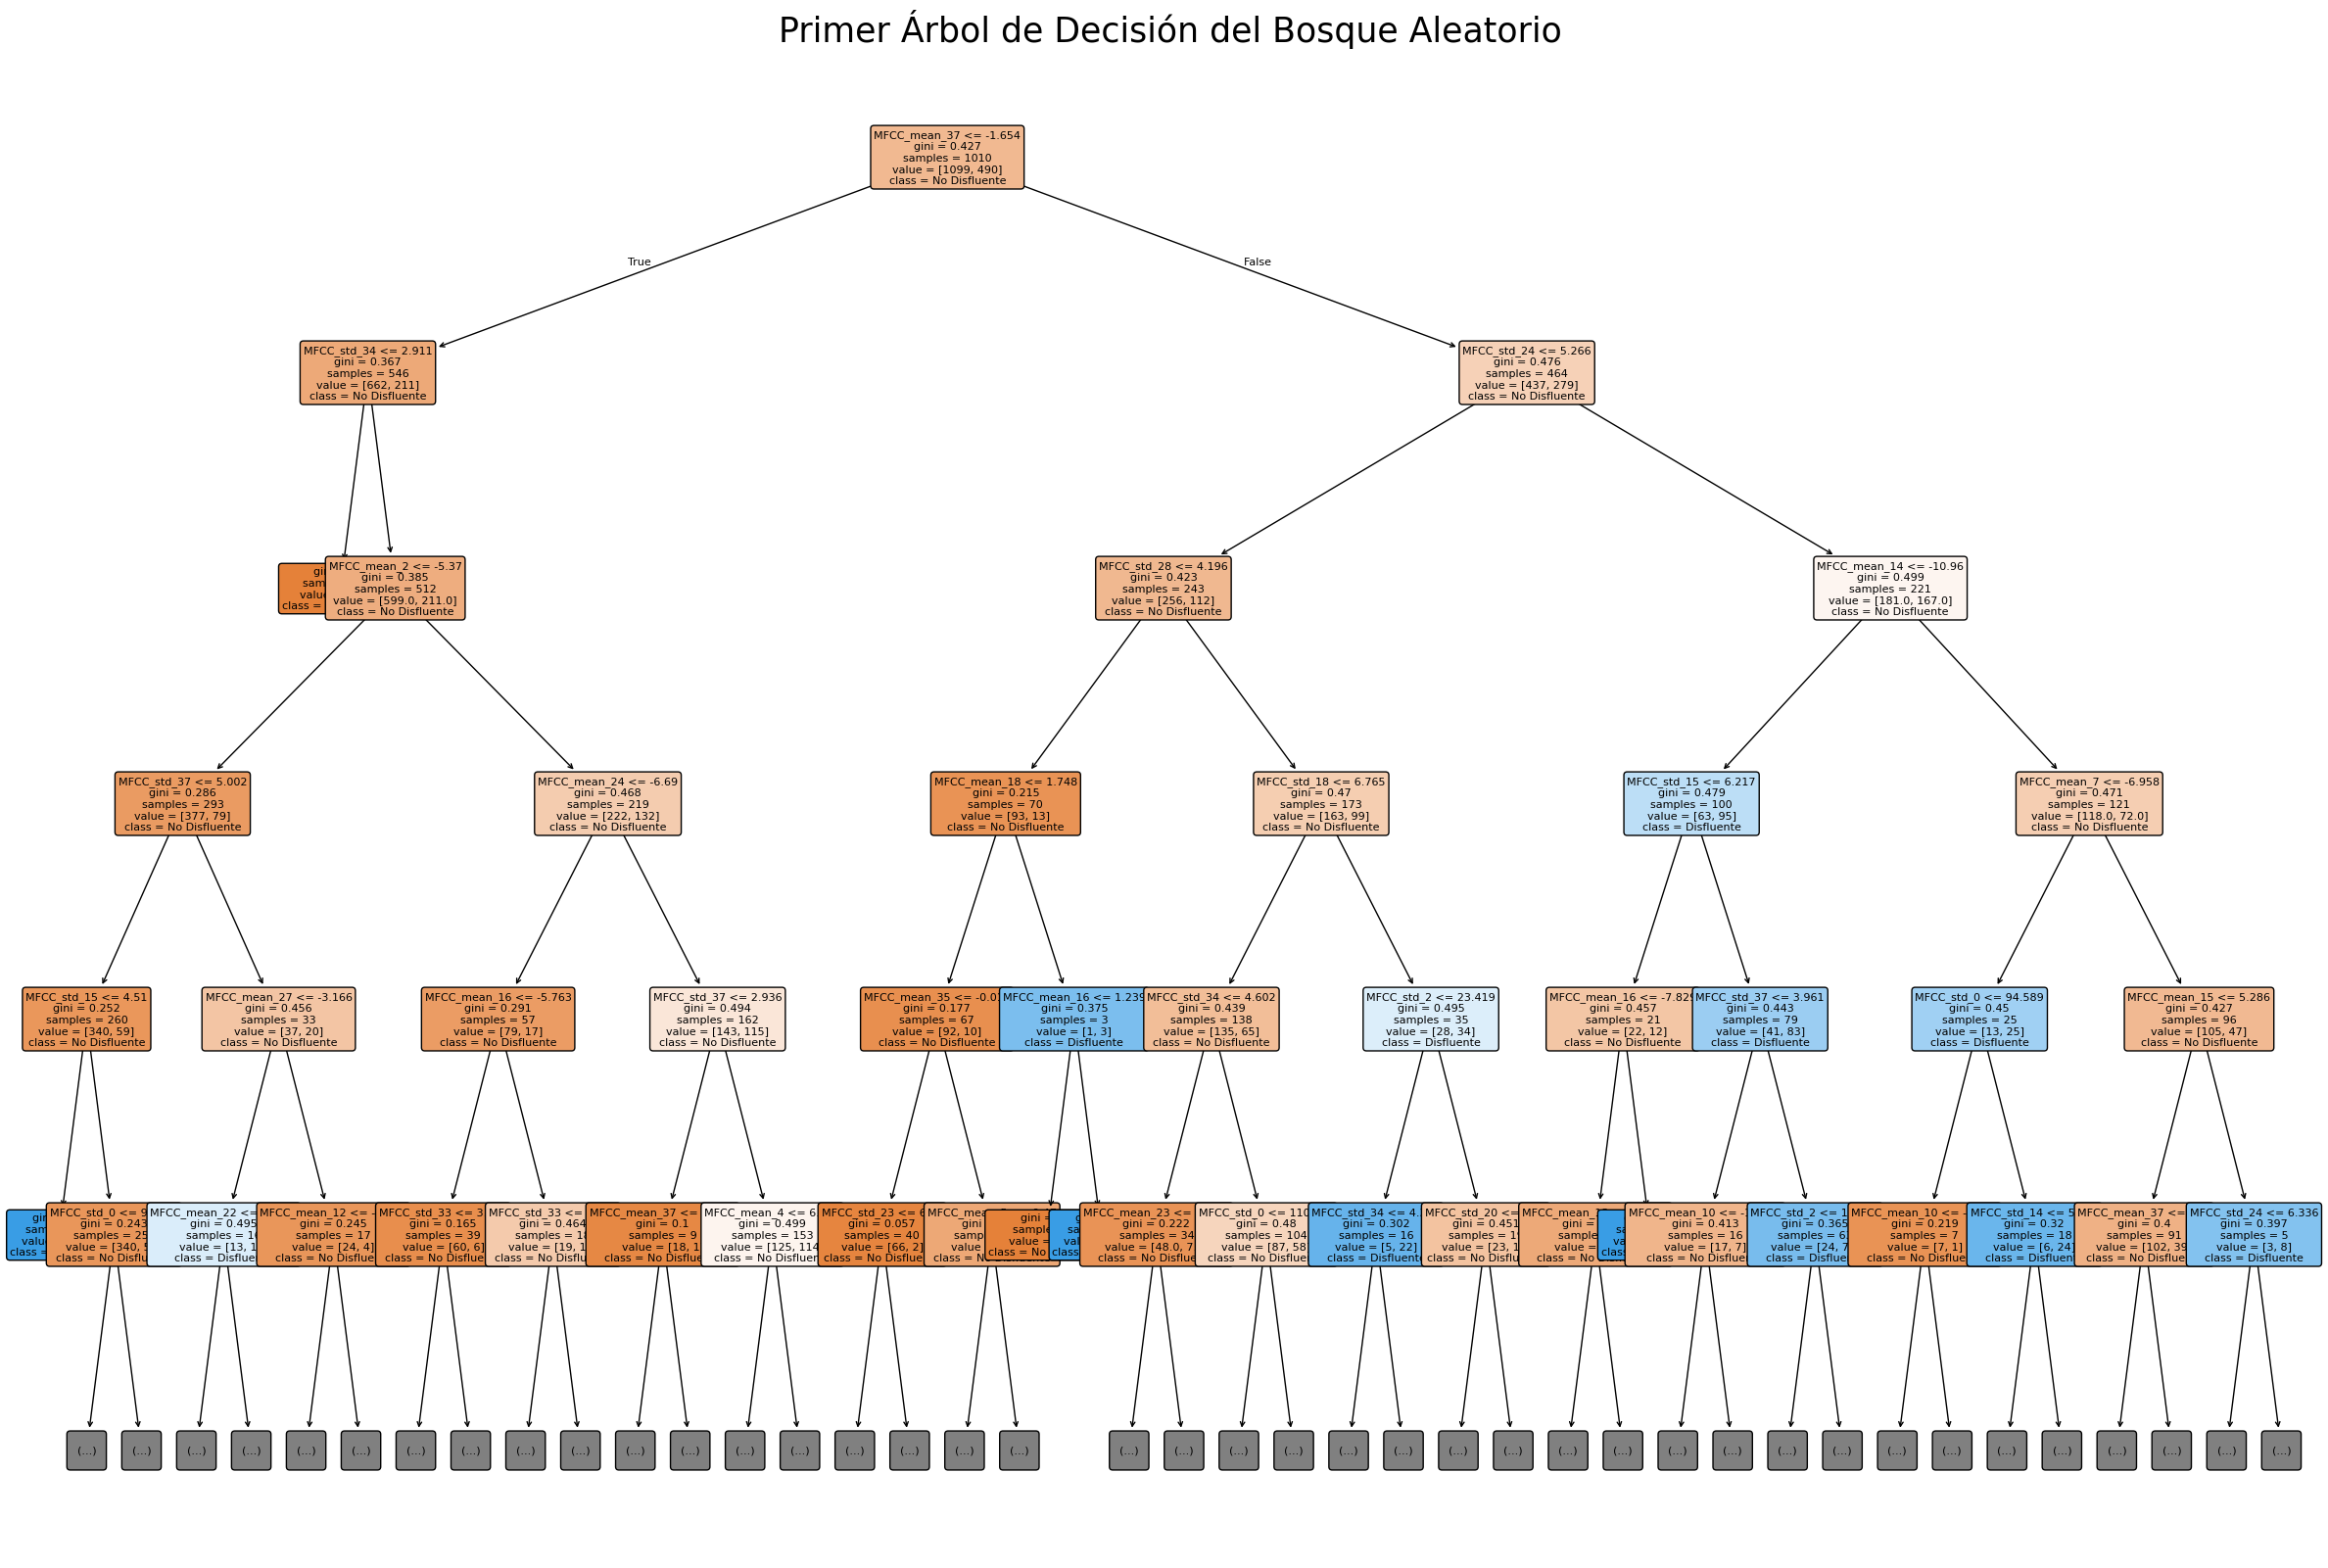

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20)) # Aumentar el tamaño para una mejor visualización

# Visualizar el primer árbol del bosque (puedes cambiar el índice [0] para ver otros árboles)
plot_tree(rf_model.estimators_[0], # Accede al primer árbol entrenado
          feature_names=mfcc_feature_names, # Nombres de las características MFCC
          class_names=['No Disfluente', 'Disfluente'], # Nombres de las clases objetivo
          filled=True, # Rellenar nodos con colores de clase
          rounded=True, # Bordes redondeados para los nodos
          fontsize=8, # Tamaño de fuente de la etiqueta del nodo
          max_depth=5 # Limitar la profundidad para hacer el árbol más legible
         )
plt.title('Primer Árbol de Decisión del Bosque Aleatorio', fontsize=25)
plt.show()

En la visualización del árbol:

*   **`feature <= threshold`**: Esta es la condición de división en cada nodo. Si la característica cumple la condición, el camino es hacia la izquierda; de lo contrario, es hacia la derecha.
*   **`gini`**: Es la impureza Gini del nodo. Un valor de 0 significa que todas las muestras en ese nodo pertenecen a la misma clase.
*   **`samples`**: El número de muestras que llegan a ese nodo.
*   **`value`**: Muestra la distribución de las clases en el nodo. Por ejemplo, `[100, 50]` significa 100 muestras de la clase 0 ('No Disfluente') y 50 muestras de la clase 1 ('Disfluente').
*   **`class`**: La clase mayoritaria en el nodo, que sería la predicción si este nodo fuera una hoja.

### Feature Extraction: Wav2Vec Embeddings

Ahora, en lugar de MFCCs, utilizaremos embeddings generados por un modelo pre-entrenado **wav2vec**. Estos embeddings capturan representaciones de audio de alto nivel que suelen ser mucho más potentes para tareas de clasificación de voz.

In [ ]:
# Instalar librerías necesarias
!pip install transformers soundfile

In [ ]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import soundfile as sf
import torch

### Cargar el Modelo Wav2Vec2 pre-entrenado

Cargaremos un procesador y un modelo Wav2Vec2 pre-entrenado. El procesador se encarga de preparar el audio (muestreo, normalización, etc.) y el modelo generará los embeddings.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Puedes elegir diferentes modelos, 'facebook/wav2vec2-base-960h' es un buen punto de partida.
# Para español, podrías considerar modelos específicos si los encuentras, pero el base funciona bien.
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Función para extraer Embeddings de Wav2Vec

Crearemos una función que tome la ruta de un archivo de audio, lo cargue, lo preprocese con el `Wav2Vec2Processor` y luego extraiga los embeddings de la última capa oculta del `Wav2Vec2Model`.

In [ ]:
def extract_wav2vec_embeddings(audio_path, target_sr=16000):
    if not os.path.exists(audio_path):
        # print(f"Warning: Audio file not found: {audio_path}. Skipping feature extraction.")
        return None
    try:
        # Cargar audio con soundfile
        audio_input, sample_rate = sf.read(audio_path)

        # Si el sample_rate no es el target, resamplear (Wav2Vec2 espera 16kHz)
        if sample_rate != target_sr:
            audio_input = librosa.resample(y=audio_input, orig_sr=sample_rate, target_sr=target_sr)

        # Preprocesar el audio
        inputs = processor(audio_input, sampling_rate=target_sr, return_tensors="pt").to(device)

        # Generar embeddings
        with torch.no_grad():
            outputs = model(**inputs)

        # Extraer embeddings del hidden state de la última capa
        # Tomamos el promedio de los embeddings a lo largo de la dimensión temporal para obtener un vector de tamaño fijo
        embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        return embeddings
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

### Extracción de Embeddings para todo el Dataset

Ahora aplicaremos esta función a todos los clips de audio para obtener los embeddings de Wav2Vec para cada muestra.

In [ ]:
print("Extracting Wav2Vec embeddings from audio clips. This will take a while...")

wav2vec_data = []

for index, row in anotaciones_with_audio_paths.iterrows():
    embeddings = extract_wav2vec_embeddings(row['wav_audio_path'])
    if embeddings is not None:
        entry = {
            'wav2vec_features': embeddings,
            'is_disfluent': row['is_disfluent'] # Mantener el estado de disfluencia binario
        }
        # Opcional: añadir tipos individuales de disfluencia si es necesario para tareas futuras
        for label in disfluency_labels:
            entry[label] = row[label]
        wav2vec_data.append(entry)

wav2vec_df = pd.DataFrame(wav2vec_data)

print(f"Finished Wav2Vec embedding extraction. Number of samples with extracted embeddings: {len(wav2vec_df)}")
display(wav2vec_df.head())

Extracting Wav2Vec embeddings from audio clips. This will take a while...
Finished Wav2Vec embedding extraction. Number of samples with extracted embeddings: 4676


,wav2vec_features,is_disfluent,Prolongation,Block,SoundRep,WordRep,Interjection
0,"[-0.06832078, 0.025479028, 0.01529732, -0.0124...",0,0,0,0,0,0
1,"[-0.031501513, -0.0037415372, -0.03895294, -0....",0,0,0,0,0,0
2,"[-0.033973396, 0.007365932, -0.10345959, -0.04...",0,0,0,0,0,0
3,"[-0.07943241, 0.024246281, 0.035671193, -0.010...",0,0,0,0,0,0
4,"[-0.007887143, -0.00703573, -0.024013309, -0.0...",0,0,0,0,0,0


### Preparación de Datos para el Clasificador (Wav2Vec)

Ahora que tenemos los embeddings de Wav2Vec, dividiremos los datos en conjuntos de entrenamiento, validación y prueba, de manera similar a como lo hicimos con los MFCCs.

In [ ]:
# Separar características (X) y objetivo (y) para Wav2Vec
X_wav2vec = np.array(wav2vec_df['wav2vec_features'].tolist())
y_wav2vec = wav2vec_df['is_disfluent']

print(f"Shape of Wav2Vec features: {X_wav2vec.shape}")

# Dividir en conjuntos de entrenamiento, validación y prueba
X_train_wav2vec, X_temp_wav2vec, y_train_wav2vec, y_temp_wav2vec = train_test_split(
    X_wav2vec, y_wav2vec, test_size=0.66, random_state=42, stratify=y_wav2vec
)
X_val_wav2vec, X_test_wav2vec, y_val_wav2vec, y_test_wav2vec = train_test_split(
    X_temp_wav2vec, y_temp_wav2vec, test_size=0.5, random_state=42, stratify=y_temp_wav2vec
)

print(f"\nWav2Vec Dataset Splits:")
print(f"Train set: {len(X_train_wav2vec)} samples - Disfluent: {y_train_wav2vec.sum()} ({y_train_wav2vec.mean():.2%})")
print(f"Validation set: {len(X_val_wav2vec)} samples - Disfluent: {y_val_wav2vec.sum()} ({y_val_wav2vec.mean():.2%})")
print(f"Test set: {len(X_test_wav2vec)} samples - Disfluent: {y_test_wav2vec.sum()} ({y_test_wav2vec.mean():.2%})")

Shape of Wav2Vec features: (4676, 768)

Wav2Vec Dataset Splits:
Train set: 1589 samples - Disfluent: 470 (29.58%)
Validation set: 1543 samples - Disfluent: 456 (29.55%)
Test set: 1544 samples - Disfluent: 456 (29.53%)


In [ ]:
#export clipsinfocsv


In [ ]:
clips_info_df.to_csv(os.path.join(workspace, "clips_info.csv"), index=False)
print(f"'clips_info_df' exported to {os.path.join(workspace, 'clips_info.csv')}")

'clips_info_df' exported to /content/drive/My Drive/disfluencias/clips_info.csv
